In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import zipfile
from pathlib import Path
import pickle
import tarfile
import datetime
import numpy as np
import urllib.request
import sklearn.metrics
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import tensorboard as tb
import albumentations as A

import cv2

N_CLASSES = 200

2026-06-06 00:38:54.098506: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    print(gpus)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# import torch
# print(keras.backend.backend())
# print(f"CUDA available: {torch.cuda.is_available()}")
# if torch.cuda.is_available():
#     print(f"GPU name: {torch.cuda.get_device_name(0)}")
#     print(f"Current device index: {torch.cuda.current_device()}")

In [4]:
BATCH_SIZE = 128
HISTORY_DIR = Path('./history')
HISTORY_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR_ROOT = Path('./dataset')
DATASET_DIR_ROOT.mkdir(parents=True, exist_ok=True)
DATASET_DIR = DATASET_DIR_ROOT / 'tiny-imagenet-200'

In [5]:
def download_data():
    dataset = DATASET_DIR
    dataset_zip = dataset.with_suffix('.zip')

    if not dataset_zip.exists():
        urllib.request.urlretrieve('http://cs231n.stanford.edu/tiny-imagenet-200.zip', dataset_zip)

    if not dataset.exists():
        file = zipfile.ZipFile(dataset_zip, 'r')
        file.extractall(path=DATASET_DIR_ROOT)

In [6]:
download_data()

In [7]:
with open(DATASET_DIR / "wnids.txt", "r") as fc:
    classes = [l.strip() for l in fc.readlines() ]
classes_map = { c: i for i, c in enumerate(classes) }
classes_map

{'n02124075': 0,
 'n04067472': 1,
 'n04540053': 2,
 'n04099969': 3,
 'n07749582': 4,
 'n01641577': 5,
 'n02802426': 6,
 'n09246464': 7,
 'n07920052': 8,
 'n03970156': 9,
 'n03891332': 10,
 'n02106662': 11,
 'n03201208': 12,
 'n02279972': 13,
 'n02132136': 14,
 'n04146614': 15,
 'n07873807': 16,
 'n02364673': 17,
 'n04507155': 18,
 'n03854065': 19,
 'n03838899': 20,
 'n03733131': 21,
 'n01443537': 22,
 'n07875152': 23,
 'n03544143': 24,
 'n09428293': 25,
 'n03085013': 26,
 'n02437312': 27,
 'n07614500': 28,
 'n03804744': 29,
 'n04265275': 30,
 'n02963159': 31,
 'n02486410': 32,
 'n01944390': 33,
 'n09256479': 34,
 'n02058221': 35,
 'n04275548': 36,
 'n02321529': 37,
 'n02769748': 38,
 'n02099712': 39,
 'n07695742': 40,
 'n02056570': 41,
 'n02281406': 42,
 'n01774750': 43,
 'n02509815': 44,
 'n03983396': 45,
 'n07753592': 46,
 'n04254777': 47,
 'n02233338': 48,
 'n04008634': 49,
 'n02823428': 50,
 'n02236044': 51,
 'n03393912': 52,
 'n07583066': 53,
 'n04074963': 54,
 'n01629819': 55,
 '

In [8]:
def get_dataset_part(path_to_dir_with_annotations: Path, is_val: bool = False) -> tuple[list[Path], list[int]]:
    _path = path_to_dir_with_annotations
    assert _path.is_dir()

    metadata_path = list(_path.glob("*.txt"))[0]

    with open(metadata_path, "r") as fm:
        _md = np.loadtxt(fm, dtype=str)
        file_paths = [_path / "images" / name for name in _md[:, 0]]
        if is_val:
            name_classes = list(map(str, _md[:, 1]))
        else:
            name_classes = [_path.name] * len(file_paths)

    i_classes = [classes_map[n] for n in name_classes]

    return file_paths, i_classes

def get_train_dataset(path_to_dir_with_train_dirs: Path) -> tuple[list[Path], list[int]]:
    _path = path_to_dir_with_train_dirs
    assert _path.is_dir()

    file_paths = []
    i_classes = []
    for class_dir in _path.iterdir():
        fps, cid = get_dataset_part(class_dir)
        file_paths.extend(fps)
        i_classes.extend(cid)

    return file_paths, i_classes

In [9]:
# get_dataset_part(DATASET_DIR / "val", is_val=True)
# get_dataset_part(DATASET_DIR / "train" / "n01443537")

# td = get_train_dataset(DATASET_DIR / "train")

In [10]:
# list(map(len, td))

In [11]:
class Dataset(keras.utils.PyDataset):

    def __init__(
            self, 
            image_paths: list[Path], 
            image_classes: list[int],
            batch_size: int,
            seed: int | None = None, 
            shuffle: bool = False, 
            augmentation: A.Compose | None = None,
            **kwargs):
        super().__init__(**kwargs)
        self.shuffle = shuffle
        self.batch_size = batch_size
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.augmentation = augmentation

        self.image_paths = image_paths
        self.image_classes = np.array(image_classes)

        self.image_index = np.arange(len(image_paths))

        self.on_epoch_end()

    def make_train_dataset(batch_size: int, seed: int | None = None, shuffle: bool = False, **kwargs):
        aug = A.Compose([
            A.HorizontalFlip(p=0.5),
            # A.SquareSymmetry(p=1.0),
            A.Affine(
                scale=(0.9, 1.1), 
                rotate=30, 
                translate_percent=0.05,
                shear=(-10, 10),
                border_mode=cv2.BORDER_REFLECT,
                p=0.7,
            ),
            A.RandomBrightnessContrast(0.2),            
        ], p=1.0)

        return Dataset(*get_train_dataset(DATASET_DIR / "train"), batch_size, seed, shuffle, augmentation=aug, **kwargs)
    
    def make_validation_dataset(batch_size: int, seed: int | None = None, shuffle: bool = False, **kwargs):
        return Dataset(*get_dataset_part(DATASET_DIR / "val", is_val=True), batch_size, seed, shuffle, **kwargs)

    def __len__(self):
        return (len(self.image_paths) + self.batch_size - 1) // self.batch_size

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.image_index)
    
    def __getitem__(self, index: int):
        start = index * self.batch_size
        end = (index + 1) * self.batch_size
        batch = self.image_index[start:end]

        image_f = lambda x: x
        if self.augmentation:
            image_f = lambda x: self.augmentation(image=x)["image"]

        images = np.array([image_f(cv2.imread(self.image_paths[idx])) for idx in batch])
        return images, self.image_classes[batch]


In [12]:
train_dataset = Dataset.make_train_dataset(batch_size=BATCH_SIZE, seed=42, shuffle=True)

In [13]:
val_dataset = Dataset.make_validation_dataset(batch_size=BATCH_SIZE, seed=42, shuffle=False)

In [14]:
def res_block(inp, dim: int, name: str | None = None, is_first: bool=False):
    x = inp

    half_text = "_strides2" if is_first else ""

    x = keras.layers.Conv2D(dim // 4, 1, strides=1 + is_first, padding='same', name=f"{name}_conv_1{half_text}")(x)
    x = keras.layers.BatchNormalization(name=f"{name}_bn_1")(x)
    x = keras.layers.ReLU(name=f"{name}_swish_1")(x)

    x = keras.layers.Conv2D(dim // 4, 3, padding='same', name=f"{name}_conv_2")(x)
    x = keras.layers.BatchNormalization(name=f"{name}_bn_2")(x)
    x = keras.layers.ReLU(name=f"{name}_swish_2")(x)

    x = keras.layers.Conv2D(dim, 1, name=f"{name}_conv_3")(x)
    if (not is_first):
        x = keras.layers.Add(name=f"{name}_add")([x, inp])

    x = keras.layers.ReLU(name=f"{name}_relu_3")(x)
    x = keras.layers.Dropout(0.1, name=f"{name}_dropout")(x)

    return x

In [20]:
SEED = 42

FILTERS = 64 

x = inputs = keras.layers.Input((64, 64, 3), name='inp')

x = keras.layers.Rescaling(1./255)(x)

x = keras.layers.Conv2D(FILTERS, 7, strides=2, padding='same', name="inp_conv")(x)
x = keras.layers.BatchNormalization(name="bn_1")(x)
# x = keras.layers.MaxPool2D(3, strides=2, padding='same', name="inp_max")(x)

nums = [
    (FILTERS * 4, 1),
    (FILTERS * 8, 1),
    (FILTERS * 16, 1),
    # (FILTERS * 32, 2)
]
print(nums)

for i, (ker, times) in enumerate(nums):
    for j in range(times):
        # isf = (j == 0 and i > 0)
        isf = j == 0
        x = res_block(x, ker, name=f"conv_{i}_{j}", is_first=isf)

x = keras.layers.GlobalAveragePooling2D(name="avg_pool_end")(x)

x = keras.layers.Dropout(0.3, seed=SEED, name="dropout_1")(x)
x = keras.layers.Dense(N_CLASSES, activation='softmax', name="dense_softmax")(x)

model = keras.models.Model(inputs, x)

[(256, 1), (512, 1), (1024, 1)]


In [21]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inp (InputLayer)                │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inp_conv (Conv2D)               │ (None, 32, 32, 64)     │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_0_conv_1_strides2        │ (None, 16, 16, 64)     │         4,160 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_0_bn_1                   │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_0_swish_1 (ReLU)         │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_0_conv_2 (Conv2D)        │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_0_bn_2                   │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_0_swish_2 (ReLU)         │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_0_conv_3 (Conv2D)        │ (None, 16, 16, 256)    │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_0_relu_3 (ReLU)          │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_0_dropout (Dropout)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_0_conv_1_strides2        │ (None, 8, 8, 128)      │        32,896 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_0_bn_1                   │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_0_swish_1 (ReLU)         │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_0_conv_2 (Conv2D)        │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_0_bn_2                   │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_0_swish_2 (ReLU)         │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_0_conv_3 (Conv2D)        │ (None, 8, 8, 512)      │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_0_relu_3 (ReLU)          │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_0_dropout (Dropout)      │ (None, 8, 8, 512)      │             

 Total params: 1,507,144 (5.75 MB)

 Trainable params: 1,505,224 (5.74 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [22]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(), 
    metrics=[
        keras.metrics.SparseCategoricalAccuracy()
    ]
)

In [23]:
logdir = HISTORY_DIR / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# logdir = HISTORY_DIR / "20260531-202627"
logdir.mkdir(parents=True, exist_ok=True)
logdir

PosixPath('history/20260606-003955')

In [24]:
model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    logdir / 'model.keras',
    save_best_only=True
)

In [25]:
tb_log = logdir / 'logs'
tb_log
tensorboard_callback = keras.callbacks.TensorBoard(
    tb_log,
)
tb_log_str = str(tb_log).replace("\\", "/")
tb_log_str

'history/20260606-003955/logs'

In [26]:
%load_ext tensorboard

In [27]:
tb.notebook.list()

No known TensorBoard instances running.


In [28]:
%tensorboard --logdir {tb_log_str}

In [29]:
# import gc
# gc.collect()
# torch.cuda.empty_cache()

In [30]:
# import gc
# tf.keras.backend.clear_session()
# gc.collect()

In [31]:
# model.load_weights(model_checkpoint_callback.filepath)

In [32]:
# model.save(logdir / "model_hand_saved.keras")

In [34]:
model.fit(
    train_dataset, 
    validation_data=val_dataset, 
    batch_size=BATCH_SIZE,
    epochs=100,
    callbacks=[
        model_checkpoint_callback, 
        tensorboard_callback,
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-8),
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    ]
)

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - loss: 1.8214 - sparse_categorical_accuracy: 0.5310 - val_loss: 2.5358 - val_sparse_categorical_accuracy: 0.4183 - learning_rate: 6.2500e-05
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - loss: 1.8130 - sparse_categorical_accuracy: 0.5349 - val_loss: 2.5314 - val_sparse_categorical_accuracy: 0.4186 - learning_rate: 6.2500e-05
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - loss: 1.8100 - sparse_categorical_accuracy: 0.5354 - val_loss: 2.5318 - val_sparse_categorical_accuracy: 0.4175 - learning_rate: 6.2500e-05
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - loss: 1.8134 - sparse_categorical_accuracy: 0.5335 - val_loss: 2.5368 - val_sparse_categorical_accuracy: 0.4174 - learning_rate: 6.2500e-05
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - loss: 1.8018 - sparse_categorical_accuracy: 0.5354 - val_loss: 2.5312 - val_sparse_categorical_accuracy: 0.4171 - learning_rate: 6.2500e-05
Epoch 6/100
782

In [35]:
y_true = val_dataset.image_classes
y_pred = np.argmax(model.predict(val_dataset), axis=1)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


In [36]:
sklearn.metrics.accuracy_score(y_true, y_pred)

0.4201

In [37]:
_, ax = plt.subplots(figsize=(75, 75))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False)

plt.tight_layout()
plt.savefig(logdir / 'valid.png')

In [38]:
_, ax = plt.subplots(figsize=(75, 75))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False, normalize='true')

plt.tight_layout()
plt.savefig(logdir / 'valid_true.png')

In [39]:
accuracies = []
for i in range(N_CLASSES):
    _class = y_true == i
    accuracies.append((sklearn.metrics.accuracy_score(y_true[_class], y_pred[_class]), i))

list(sorted(accuracies))

[(0.04, 182),
 (0.06, 9),
 (0.06, 45),
 (0.06, 190),
 (0.08, 126),
 (0.1, 18),
 (0.1, 153),
 (0.1, 176),
 (0.12, 65),
 (0.12, 118),
 (0.12, 162),
 (0.14, 0),
 (0.18, 1),
 (0.18, 49),
 (0.18, 59),
 (0.18, 83),
 (0.18, 100),
 (0.18, 156),
 (0.18, 189),
 (0.2, 29),
 (0.2, 39),
 (0.2, 81),
 (0.2, 101),
 (0.2, 194),
 (0.22, 71),
 (0.22, 92),
 (0.22, 96),
 (0.22, 97),
 (0.22, 124),
 (0.22, 145),
 (0.22, 154),
 (0.24, 20),
 (0.24, 72),
 (0.24, 134),
 (0.24, 136),
 (0.24, 171),
 (0.26, 26),
 (0.26, 56),
 (0.26, 84),
 (0.26, 86),
 (0.26, 121),
 (0.26, 129),
 (0.26, 172),
 (0.26, 177),
 (0.26, 179),
 (0.28, 47),
 (0.28, 50),
 (0.28, 66),
 (0.28, 112),
 (0.28, 158),
 (0.3, 51),
 (0.3, 54),
 (0.3, 77),
 (0.3, 120),
 (0.3, 125),
 (0.3, 147),
 (0.3, 183),
 (0.3, 187),
 (0.3, 197),
 (0.32, 10),
 (0.32, 28),
 (0.32, 31),
 (0.32, 33),
 (0.32, 80),
 (0.32, 106),
 (0.32, 110),
 (0.32, 114),
 (0.32, 140),
 (0.32, 161),
 (0.32, 169),
 (0.34, 3),
 (0.34, 24),
 (0.34, 30),
 (0.34, 48),
 (0.34, 61),
 (0.34, 9

In [40]:
classes_map_inv = {v: k for k, v in classes_map.items()}
classes_map_inv[182]

'n02085620'

In [41]:
with open(DATASET_DIR / "words.txt", 'r') as f:
    words = [ l.strip().split('\t') for l in f.readlines() ]
    words = dict(words)
words

{'n00001740': 'entity',
 'n00001930': 'physical entity',
 'n00002137': 'abstraction, abstract entity',
 'n00002452': 'thing',
 'n00002684': 'object, physical object',
 'n00003553': 'whole, unit',
 'n00003993': 'congener',
 'n00004258': 'living thing, animate thing',
 'n00004475': 'organism, being',
 'n00005787': 'benthos',
 'n00005930': 'dwarf',
 'n00006024': 'heterotroph',
 'n00006150': 'parent',
 'n00006269': 'life',
 'n00006400': 'biont',
 'n00006484': 'cell',
 'n00007347': 'causal agent, cause, causal agency',
 'n00007846': 'person, individual, someone, somebody, mortal, soul',
 'n00015388': 'animal, animate being, beast, brute, creature, fauna',
 'n00017222': 'plant, flora, plant life',
 'n00019046': 'native',
 'n00019128': 'natural object',
 'n00019613': 'substance',
 'n00020090': 'substance',
 'n00020827': 'matter',
 'n00021265': 'food, nutrient',
 'n00021734': 'nutrient',
 'n00021939': 'artifact, artefact',
 'n00022903': 'article',
 'n00023100': 'psychological feature',
 'n0002

In [42]:
def plot_pic_from(dataset: Dataset, class_idx: int, nrows: int = 2, ncols: int = 4):
    class_name = classes_map_inv[class_idx]
    class_words = words[class_name]

    rng = np.random.default_rng()
    mask = dataset.image_classes == class_idx
    idx = np.where(mask)[0]
    idx = rng.choice(idx, size=nrows * ncols, replace=False)

    fig, ax = plt.subplots(nrows, ncols, figsize=(16, 8))

    print(class_name)
    print(class_words)

    for i, k in enumerate(idx):
        img = cv2.imread(dataset.image_paths[k])
        _ax = ax[i // ncols, i % ncols]
        _ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        _ax.axis('off')
        _ax.set_title(f"{y_pred[k]}\n{words[classes_map_inv[y_pred[k]]]}")

n02085620
Chihuahua


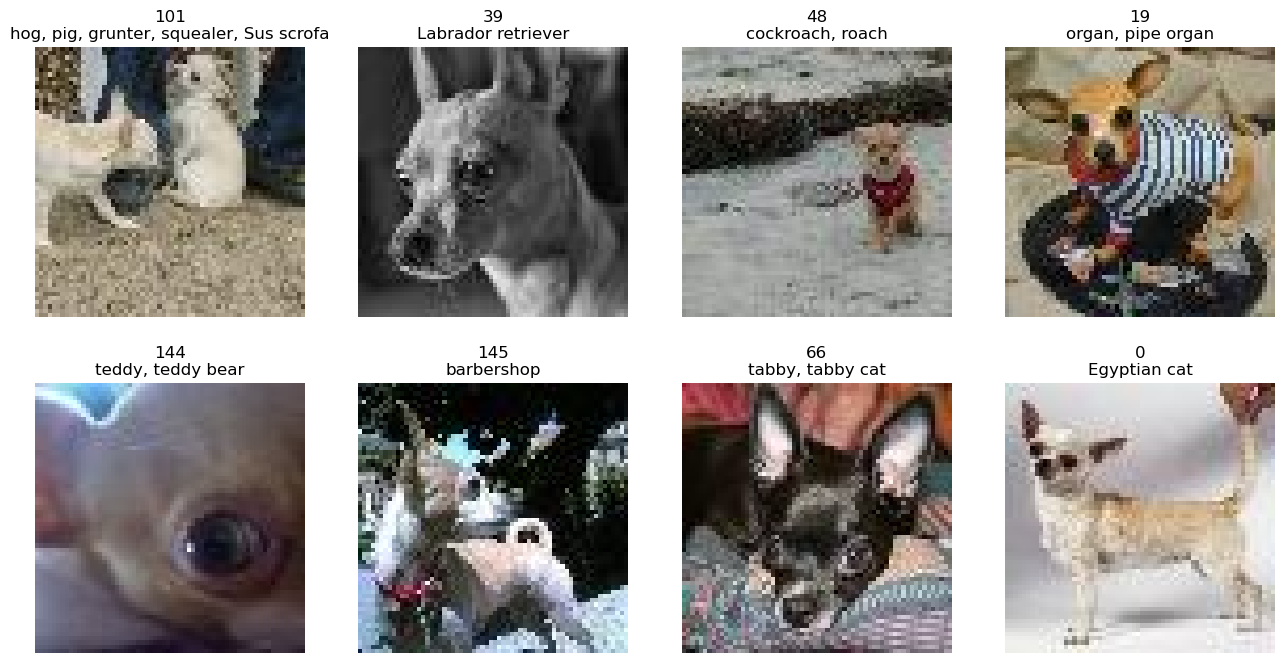

In [53]:
plot_pic_from(val_dataset, 182)